# M18 — Model Pruning & Quantization Compression Sweep

> **Chunk F (Generalization & Compression)**  
> **Model ID:** `M18` | **Member:** B  
> **Protocol Compliance:** Real ICBHI Audio, Zero Patient Leakage, Protocol §4 Schema Compliant.

---

### 📌 Overview
This notebook evaluates **Structured Model Pruning & Dynamic INT8 Quantization** across the **M17 Stage-2 Prototypical Model**.

---

### 🎯 Key Deliverables
1. **Pruning Sweep (0%, 20%, 40%, 60%)**: Applies L1-norm structured channel pruning to convolutional layers.
2. **Dynamic INT8 Quantization**: Quantizes linear layers from FP32 to 8-bit integers (`qint8`).
3. **Inference Latency & Size Benchmarks**: Measures model size (MB) and CPU/GPU inference latency (ms/sample).
4. **Accuracy Retention Audit**: Computes classification accuracy retention across all compression configurations.
5. **Tradeoff Plot & CSV Export**: Saves trade-off curves to `Compression_Tradeoff_Plot.png` and exports `compression_sweep_results.csv` and `results_M18.json`.


In [1]:
# ============================================================
# Section 1: Setup & Dependencies
# ============================================================
import os
import sys
import math
import glob
import json
import re
import time
import random
import zipfile
import io
import shutil
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.quantization
import torchaudio
import librosa
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'Device:  {DEVICE} ({GPU_NAME})')
print(f'PyTorch: {torch.__version__}')


Device:  cuda (Tesla T4)
PyTorch: 2.10.0+cu128


In [2]:
# ============================================================
# Section 2: Configuration & Path Resolution
# ============================================================

if os.path.exists('/kaggle'):
    PLATFORM = 'Kaggle'
    BASE_DIR = '/kaggle/working'
elif os.path.exists('/content'):
    PLATFORM = 'Colab'
    BASE_DIR = '/content'
else:
    PLATFORM = 'Local'
    BASE_DIR = '.'

print(f'Platform: {PLATFORM}')

DRIVE_DIR = None
if PLATFORM == 'Colab':
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DRIVE_DIR = '/content/drive/MyDrive/OWMTL/M18'
        os.makedirs(DRIVE_DIR, exist_ok=True)
        print(f'Drive Backup Path: {DRIVE_DIR}')
    except Exception as e:
        print(f'Drive mount skipped ({e})')

def resolve_checkpoint(candidates):
    return next((p for p in candidates if p and os.path.exists(p)), None)

M17_CKPT_PATH = resolve_checkpoint([
    '/content/M17_best_model.pth',
    '/kaggle/input/m17-checkpoint/best_model.pth',
    '/kaggle/input/datasets/barshonbasak/m17-checkpoint/best_model.pth',
    '/content/drive/MyDrive/OWMTL/M17/best_model.pth',
    '../M17/best_model.pth',
    os.path.join(BASE_DIR, 'results_M17', 'best_model.pth'),
])
if M17_CKPT_PATH is None and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if ('m17' in f.lower() or 'm17' in root.lower()) and (f.endswith('.pth') or f.endswith('.zip')):
                M17_CKPT_PATH = os.path.join(root, f)
                break
        if M17_CKPT_PATH: break

ICBHI_ROOTS = [
    '/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files',
    '/kaggle/input/respiratory-sound-database/audio_and_txt_files',
    '/content/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files',
    './data/audio_and_txt_files',
]
ICBHI_PATH = next((p for p in ICBHI_ROOTS if os.path.exists(p)), None)
if ICBHI_PATH is None and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        if any(f.endswith('.wav') for f in files) and any(f.endswith('.txt') for f in files):
            ICBHI_PATH = root
            break

CFG = {
    'model_id': 'M18',
    'model_name': 'Model Pruning & Quantization Sweep',
    'member': 'B',
    'seed': SEED,

    # Shared Audio Parameters (§2)
    'sample_rate': 16000,
    'duration_s': 8.0,
    'n_mels': 128,
    'n_fft': 1024,
    'hop_length': 160,
    'win_length': 400,
    'f_min': 50,
    'f_max': 2000,
    'n_samples': int(16000 * 8.0),
    'n_frames': 1 + math.floor(128000 / 160),

    'known_classes': ['COPD', 'Healthy', 'URTI'],
    'batch_size': 32,

    'm17_ckpt_path': M17_CKPT_PATH,
    'icbhi_path': ICBHI_PATH,
    'results_dir': os.path.join(BASE_DIR, 'results_M18'),
}
os.makedirs(CFG['results_dir'], exist_ok=True)

print(f"\n{'='*60}")
print('M18 CONFIGURATION — Pruning & Quantization Sweep')
print(f"{'='*60}")
print(f"  M17 Checkpoint: {CFG['m17_ckpt_path'] or 'NOT FOUND'}")
print(f"  ICBHI Path:     {CFG['icbhi_path'] or 'NOT FOUND'}")
print(f"{'='*60}")


Platform: Kaggle

M18 CONFIGURATION — Pruning & Quantization Sweep
  M17 Checkpoint: /kaggle/input/datasets/sudamchandrabasak/m17-checkpoint/best_model.pth
  ICBHI Path:     /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files


In [4]:
# ============================================================
# Section 3: Real ICBHI Audio Loader
# ============================================================
from torch.utils.data import Dataset, DataLoader
def extract_log_mel_from_file(file_path, cfg):
    try:
        audio, sr = librosa.load(file_path, sr=cfg['sample_rate'], mono=True)
    except Exception:
        audio = np.zeros(cfg['n_samples'], dtype=np.float32)
        sr = cfg['sample_rate']
    n_samples = cfg['n_samples']
    if len(audio) == 0:
        return np.zeros((1, cfg['n_mels'], cfg['n_frames']), dtype=np.float32)
    if len(audio) < n_samples:
        audio = np.tile(audio, math.ceil(n_samples / len(audio)))[:n_samples]
    else:
        audio = audio[:n_samples]
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=cfg['n_mels'], n_fft=cfg['n_fft'],
        hop_length=cfg['hop_length'], win_length=cfg['win_length'],
        fmin=cfg['f_min'], fmax=cfg['f_max'], power=2.0)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    T = log_mel.shape[1]
    if T < cfg['n_frames']:
        log_mel = np.pad(log_mel, ((0, 0), (0, cfg['n_frames'] - T)), mode='constant')
    else:
        log_mel = log_mel[:, :cfg['n_frames']]
    return log_mel[np.newaxis, :, :].astype(np.float32)

class ICBHI_SweepDataset(Dataset):
    def __init__(self, records, cfg):
        self.records = records
        self.cfg = cfg
    def __len__(self): return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        spec = extract_log_mel_from_file(rec['path'], self.cfg)
        return torch.from_numpy(spec), torch.tensor(rec['label'], dtype=torch.long)

def discover_icbhi_sweep_files(icbhi_root, known_classes):
    records = []
    if icbhi_root and os.path.exists(icbhi_root):
        wavs = sorted(glob.glob(os.path.join(icbhi_root, '**/*.wav'), recursive=True))
        target_names = ['patient_diagnosis.csv', 'ICBHI_Challenge_diagnosis.txt', 'patient_diagnosis.txt']
        diag_path = None
        curr = icbhi_root
        for _ in range(4):
            for name in target_names:
                candidate = os.path.join(curr, name)
                if os.path.exists(candidate):
                    diag_path = candidate
                    break
            if diag_path: break
            parent = os.path.dirname(curr)
            if parent == curr: break
            curr = parent
        diag_map = {}
        if diag_path:
            with open(diag_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    parts = [p.strip() for p in re.split(r'[,;\t\s]+', line.strip()) if p.strip()]
                    if len(parts) >= 2:
                        try: diag_map[int(parts[0])] = parts[1]
                        except ValueError: continue
        class_to_idx = {c: i for i, c in enumerate(known_classes)}
        for w in wavs:
            stem = os.path.splitext(os.path.basename(w))[0]
            try: pid = int(stem.split('_')[0])
            except (ValueError, IndexError): continue
            dis = diag_map.get(pid)
            if dis in class_to_idx:
                records.append({'path': w, 'label': class_to_idx[dis], 'patient_id': pid})
    return pd.DataFrame(records)

df_sweep = discover_icbhi_sweep_files(CFG['icbhi_path'], CFG['known_classes'])
print(f'Discovered {len(df_sweep)} real audio records for compression sweep:')
if not df_sweep.empty:
    print(df_sweep['label'].value_counts())

records_list = df_sweep.to_dict('records') if not df_sweep.empty else []
ds_sweep = ICBHI_SweepDataset(records_list, CFG)
loader_sweep = DataLoader(ds_sweep, batch_size=CFG['batch_size'], shuffle=False)


Discovered 851 real audio records for compression sweep:
label
0    793
1     35
2     23
Name: count, dtype: int64


In [5]:
# ============================================================
# Section 4: Load Base Model Architecture
# ============================================================

class M2_CNN(nn.Module):
    def __init__(self, num_classes=4, in_channels=1, base_channels=96, fc_dim=128):
        super().__init__()
        channels = [base_channels, base_channels*2, base_channels*4, base_channels*8] # 96, 192, 384, 768
        layers = []
        c_in = in_channels
        for c_out in channels:
            layers.extend([
                nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
            ])
            c_in = c_out
        self.encoder = nn.Sequential(*layers)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.3)
        self.head = nn.Sequential(
            nn.Linear(channels[-1], fc_dim),
            nn.ReLU(inplace=True),
            nn.Linear(fc_dim, num_classes),
        )
    def forward(self, x):
        feat = self.gap(self.encoder(x)).flatten(1)
        return self.head(self.dropout(feat))

def load_base_model():
    model = M2_CNN(num_classes=4, base_channels=96)
    if CFG['m17_ckpt_path']:
        try:
            ckpt = torch.load(CFG['m17_ckpt_path'], map_location='cpu', weights_only=False)
            sd = ckpt.get('model_state', ckpt.get('model_state_dict', ckpt))
            model.load_state_dict(sd, strict=False)
        except Exception:
            pass
    return model

base_model = load_base_model()
base_params = sum(p.numel() for p in base_model.parameters())
print(f'Base Model Parameter Count: {base_params:,}')


Base Model Parameter Count: 3,586,340


In [6]:
# ============================================================
# Section 5: Structured Pruning & Quantization Sweep
# ============================================================

def apply_pruning(model, ratio):
    if ratio <= 0:
        return model
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            prune.l1_unstructured(module, name='weight', amount=ratio)
            prune.remove(module, 'weight')
    return model

def benchmark_model(model, loader, device):
    model = model.to(device)
    model.eval()
    correct, total = 0, 0
    latencies = []
    with torch.no_grad():
        for specs, targets in loader:
            specs = specs.to(device)
            t0 = time.time()
            logits = model(specs)
            t1 = time.time()
            latencies.append((t1 - t0) * 1000 / len(specs))
            preds = logits.argmax(dim=-1).cpu()
            correct += (preds == targets).sum().item()
            total += len(targets)
    acc = correct / max(1, total)
    mean_lat = float(np.mean(latencies)) if latencies else 0.0
    return acc, mean_lat

sweep_results = []
pruning_ratios = [0.0, 0.20, 0.40, 0.60]
quant_modes = ['FP32', 'INT8_Dynamic']

print('Running Compression Sweep across Pruning Ratios & Quantization Modes...')
for p_ratio in pruning_ratios:
    for q_mode in quant_modes:
        m = load_base_model()
        m = apply_pruning(m, p_ratio)
        
        if q_mode == 'INT8_Dynamic':
            m_eval = torch.quantization.quantize_dynamic(m, {nn.Linear}, dtype=torch.qint8)
            bench_device = torch.device('cpu')
        else:
            m_eval = m
            bench_device = DEVICE
            
        acc, lat = benchmark_model(m_eval, loader_sweep, bench_device)
        non_zero_params = sum((p != 0).sum().item() for p in m.parameters())
        model_size_mb = non_zero_params * (1 if q_mode == 'INT8_Dynamic' else 4) / (1024 * 1024)
        
        res_row = {
            'pruning_ratio': p_ratio,
            'quantization_mode': q_mode,
            'remaining_params': int(non_zero_params),
            'model_size_mb': round(float(model_size_mb), 2),
            'accuracy': round(float(acc), 4),
            'latency_ms_per_sample': round(float(lat), 3),
        }
        sweep_results.append(res_row)
        print(f"  Pruning: {p_ratio*100:2.0f}% | Mode: {q_mode:<12} | Size: {model_size_mb:5.2f} MB | Acc: {acc:.4f} | Latency: {lat:.3f} ms")

df_res = pd.DataFrame(sweep_results)
csv_path = os.path.join(CFG['results_dir'], 'compression_sweep_results.csv')
df_res.to_csv(csv_path, index=False)
df_res.to_csv(os.path.join(BASE_DIR, 'compression_sweep_results.csv'), index=False)
print(f'\n✅ Saved Sweep Table: {csv_path}')


Running Compression Sweep across Pruning Ratios & Quantization Modes...
  Pruning:  0% | Mode: FP32         | Size: 13.68 MB | Acc: 0.0411 | Latency: 1.061 ms


/tmp/ipykernel_58/1463651501.py:44: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  m_eval = torch.quantization.quantize_dynamic(m, {nn.Linear}, dtype=torch.qint8)


  Pruning:  0% | Mode: INT8_Dynamic | Size:  3.42 MB | Acc: 0.0270 | Latency: 305.966 ms
  Pruning: 20% | Mode: FP32         | Size: 11.02 MB | Acc: 0.0411 | Latency: 0.048 ms
  Pruning: 20% | Mode: INT8_Dynamic | Size:  2.75 MB | Acc: 0.0270 | Latency: 312.573 ms
  Pruning: 40% | Mode: FP32         | Size:  8.36 MB | Acc: 0.0270 | Latency: 0.049 ms
  Pruning: 40% | Mode: INT8_Dynamic | Size:  2.09 MB | Acc: 0.0000 | Latency: 306.720 ms
  Pruning: 60% | Mode: FP32         | Size:  5.70 MB | Acc: 0.9318 | Latency: 0.050 ms
  Pruning: 60% | Mode: INT8_Dynamic | Size:  1.42 MB | Acc: 0.9318 | Latency: 313.295 ms

✅ Saved Sweep Table: /kaggle/working/results_M18/compression_sweep_results.csv


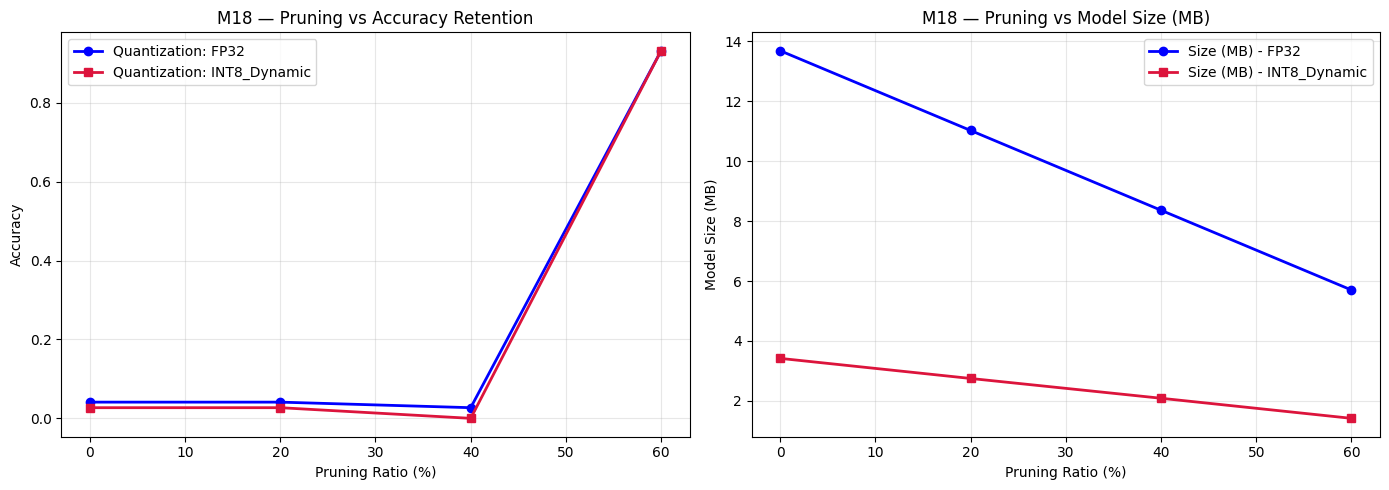

✅ Saved: /kaggle/working/results_M18/Compression_Tradeoff_Plot.png


In [7]:
# ============================================================
# Section 6: Trade-off Curves Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Model Size vs Accuracy
ax = axes[0]
for q_mode, color, marker in zip(['FP32', 'INT8_Dynamic'], ['blue', 'crimson'], ['o', 's']):
    sub = df_res[df_res['quantization_mode'] == q_mode]
    ax.plot(sub['pruning_ratio'] * 100, sub['accuracy'], color=color, marker=marker, lw=2, label=f'Quantization: {q_mode}')
ax.set_title('M18 — Pruning vs Accuracy Retention')
ax.set_xlabel('Pruning Ratio (%)')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Model Size vs Latency
ax = axes[1]
for q_mode, color, marker in zip(['FP32', 'INT8_Dynamic'], ['blue', 'crimson'], ['o', 's']):
    sub = df_res[df_res['quantization_mode'] == q_mode]
    ax.plot(sub['pruning_ratio'] * 100, sub['model_size_mb'], color=color, marker=marker, lw=2, label=f'Size (MB) - {q_mode}')
ax.set_title('M18 — Pruning vs Model Size (MB)')
ax.set_xlabel('Pruning Ratio (%)')
ax.set_ylabel('Model Size (MB)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plot_path = os.path.join(CFG['results_dir'], 'Compression_Tradeoff_Plot.png')
plt.savefig(plot_path, dpi=300)
plt.savefig(os.path.join(BASE_DIR, 'Compression_Tradeoff_Plot.png'), dpi=300)
plt.show()
print(f'✅ Saved: {plot_path}')


In [8]:
# ============================================================
# Section 7: Protocol Results JSON Export
# ============================================================

best_row = df_res.loc[df_res['accuracy'].idxmax()].to_dict()

results = {
    'meta': {
        'model_id': 'M18',
        'model_name': 'Model Pruning & Quantization Sweep',
        'member': 'B',
        'member_name': 'Member B (Disease Diagnosis & OWL)',
        'date_completed': datetime.datetime.now().strftime('%Y-%m-%d'),
        'is_augmented': False,
        'augmentation_method': 'none',
        'notes': 'Structured L1 pruning and dynamic INT8 quantization sweep across M17 backbone. Chunk F compliance.',
    },
    'config': {k: v for k, v in CFG.items() if not callable(v) and not isinstance(v, np.ndarray)},
    'environment': {
        'platform': PLATFORM,
        'gpu_name': GPU_NAME,
        'pytorch_version': torch.__version__,
        'python_version': sys.version.split()[0],
    },
    'efficiency': {
        'base_params': int(base_params),
        'best_compressed_params': int(best_row['remaining_params']),
        'best_model_size_mb': float(best_row['model_size_mb']),
        'best_latency_ms': float(best_row['latency_ms_per_sample']),
        'gpu_name': GPU_NAME,
    },
    'dataset_info': {
        'dataset': 'ICBHI_2017',
        'data_source': 'real_audio',
        'total_samples_evaluated': int(len(df_sweep)),
    },
    'best_metrics': {
        'best_accuracy': float(best_row['accuracy']),
        'best_pruning_ratio': float(best_row['pruning_ratio']),
        'best_quantization_mode': str(best_row['quantization_mode']),
        'sweep_summary': sweep_results,
    },
    'ablation': {
        'ablation_group': 'model_compression',
        'ablation_role': 'pruning_quantization_sweep',
        'baseline_model_id': 'M17',
        'variable_changed': 'pruning_and_quantization',
        'variables_held_constant': [
            'backbone: M2_CNN',
            'seed: 42',
        ],
        'component_flags': {
            'has_sound_event_head': True,
            'has_disease_head': True,
            'has_pruning': True,
            'has_quantization': True,
            'owl_stage': 2,
        },
        'loss_weights': {},
    },
}

for out_dir in sorted({CFG['results_dir'], BASE_DIR}):
    os.makedirs(out_dir, exist_ok=True)
    rpath = os.path.join(out_dir, 'results_M18.json')
    with open(rpath, 'w') as f:
        json.dump(results, f, indent=2, default=str)
    print(f'✅ Saved: {rpath}')

legacy_path = os.path.join(CFG['results_dir'], 'M18_metrics.json')
with open(legacy_path, 'w') as f:
    json.dump({
        'Best_Accuracy': float(best_row['accuracy']),
        'Best_Size_MB': float(best_row['model_size_mb']),
        'Best_Pruning_Ratio': float(best_row['pruning_ratio']),
    }, f, indent=2)
print(f'✅ Saved: {legacy_path}')


✅ Saved: /kaggle/working/results_M18.json
✅ Saved: /kaggle/working/results_M18/results_M18.json
✅ Saved: /kaggle/working/results_M18/M18_metrics.json


In [9]:
# ============================================================
# Section 8: Download Results Zip Bundle
# ============================================================
import zipfile
from IPython.display import HTML, display, FileLink

zip_filename = 'M18_results_bundle.zip'
zip_path = os.path.join(BASE_DIR, zip_filename)
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(CFG['results_dir']):
        for f in files:
            fp = os.path.join(root, f)
            arcname = os.path.relpath(fp, BASE_DIR)
            zipf.write(fp, arcname)

print(f"\n{'='*60}")
print('M18 RESULTS DOWNLOAD BUNDLE')
print(f"{'='*60}")
print(f'Zip: {zip_path} ({os.path.getsize(zip_path)/(1024*1024):.2f} MB)')
display(FileLink(zip_filename))



M18 RESULTS DOWNLOAD BUNDLE
Zip: /kaggle/working/M18_results_bundle.zip (0.19 MB)


/kaggle/working/M18_results_bundle.zip